In [141]:
import numpy as np
from IPython.display import display
import sympy as sp
import seaborn as sns


x_sym, y_sym, z_sym = sp.symbols("x y z")

y = lambda x: (1 + x) * np.exp(x * x)
f = (1 + x_sym) * sp.exp(x_sym * x_sym)

start, end = 0, 1
eps = 1e-3
h = 0.1

x = np.arange(start, end + h, h)

$
\begin{cases}
y'' - 4x y' + (4x^2 - 2)y = 0, \\
y(0) = 1, \\
y'(0) = 1, \\
x \in [0,1], \\
h = 0.1,
\end{cases}
\qquad
y = (1 + x)e^{x^2}
$


## Метод Эйлера второго порядка точности

In [142]:
f_der_1 = lambda z: z
f_der_2 = lambda x, y, z: 4 * x * z - (4 * x * x - 2) * y

y_etalon_f = y(x)

In [143]:
def euler(y_der_1, y_der_2, x, y0, z0, h):
    y = np.zeros(len(x), dtype=np.float64)
    z = np.zeros(len(x), dtype=np.float64)
    y[0], z[0] = y0, z0

    for i in range(1, len(x)):
        x_k_1_2 = x[i - 1] + h / 2
        y_k_1_2 = y[i - 1] + h / 2 * y_der_1(z[i - 1])
        z_k_1_2 = z[i - 1] + h / 2 * y_der_2(x[i - 1], y[i - 1], z[i - 1])

        y[i] = y[i - 1] + h * y_der_1(z_k_1_2)
        z[i] = z[i - 1] + h * y_der_2(x_k_1_2, y_k_1_2, z_k_1_2)

    return y, z

In [144]:
y_euler, z_euler = euler(f_der_1, f_der_2, x, 1, 1, h)

<Axes: >

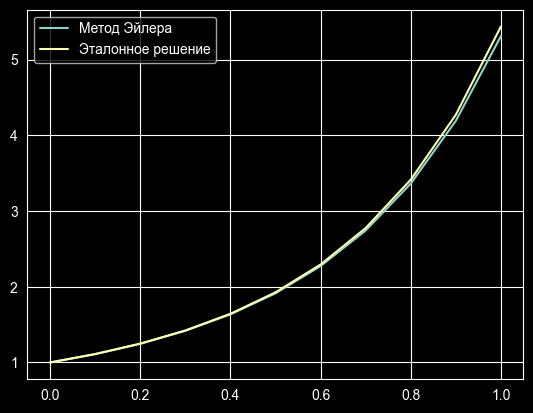

In [145]:
sns.lineplot(x=x, y=y_euler, label='Метод Эйлера')
sns.lineplot(x=x, y=y_etalon_f, label='Эталонное решение')

## Метод Рунге-Кутта четвёртого порядка точности

In [146]:
def runge_kutta(y_der_1, y_der_2, x, y0, z0, h):
    y = np.zeros(len(x), dtype=np.float64)
    z = np.zeros(len(x), dtype=np.float64)

    y[0], z[0] = y0, z0

    for i in range(1, len(x)):
        K_k_1 = h * y_der_1(z[i - 1])
        L_k_1 = h * y_der_2(x[i - 1], y[i - 1], z[i - 1])


        K_k_2 = h * y_der_1(z[i - 1] + L_k_1 / 2)

        L_k_2 = h * y_der_2(x[i - 1] + h / 2, y[i - 1] + K_k_1 / 2, z[i - 1] + L_k_1 / 2)


        K_k_3 = h * y_der_1(z[i - 1] + L_k_2 / 2)

        L_k_3 = h * y_der_2(x[i - 1] + h / 2, y[i - 1] + K_k_2 / 2, z[i - 1] + L_k_2 / 2)


        K_k_4 = h * y_der_1(z[i - 1] + L_k_3)

        L_k_4 = h * y_der_2(x[i - 1] + h, y[i - 1] + K_k_3, z[i - 1] + L_k_3)


        y_delta = (K_k_1 + 2 * K_k_2 + 2 * K_k_3 + K_k_4) / 6
        z_delta = (L_k_1 + 2 * L_k_2 + 2 * L_k_3 + L_k_4) / 6


        y[i] = y[i - 1] + y_delta
        z[i] = z[i - 1] + z_delta

    return y, z

In [147]:
y_runge_kutta, z_runge_kutta = runge_kutta(f_der_1, f_der_2, x, 1, 1, h)

<Axes: >

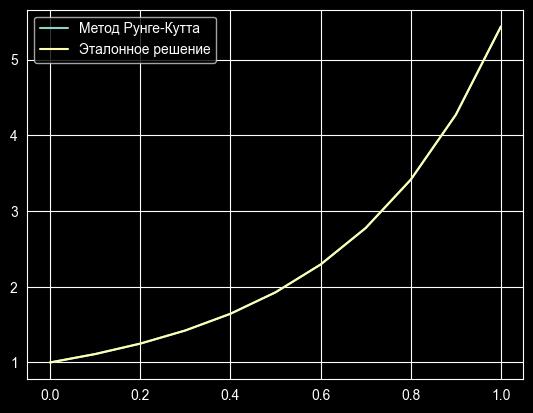

In [148]:
sns.lineplot(x=x, y=y_runge_kutta, label='Метод Рунге-Кутта')
sns.lineplot(x=x, y=y_etalon_f, label='Эталонное решение')

## Метод Адамса четвёртого порядка точности

In [149]:
def adams(y_der_1, y_der_2, x, y_start, z_start, h):
    y = np.concat((y_start, np.zeros(len(x) - 4, dtype=np.float64)))
    z = np.concat((z_start, np.zeros(len(x) - 4, dtype=np.float64)))


    for i in range(4, len(x)):
        y[i] = y[i - 1] + (h / 24) * (
            55 * y_der_1(z[i - 1])
            - 59 * y_der_1(z[i - 2])
            + 37 * y_der_1(z[i - 3])
            - 9 * y_der_1(z[i - 4])
        )

        z[i] = z[i - 1] + (h / 24) * (
            55 * y_der_2(x[i - 1], y[i - 1], z[i - 1])
            - 59 * y_der_2(x[i - 2], y[i - 2], z[i - 2])
            + 37 * y_der_2(x[i - 3], y[i - 3], z[i - 3])
            - 9 * y_der_2(x[i - 4], y[i - 4], z[i - 4])
        )

    return y, z

In [150]:
y_adams, z_adams = adams(f_der_1, f_der_2, x, y_runge_kutta[:4], z_runge_kutta[:4], h)

<Axes: >

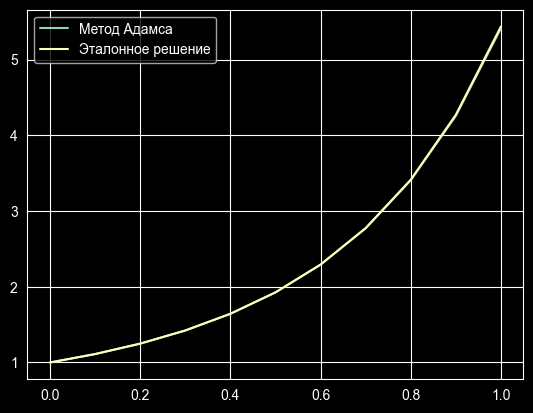

In [151]:
sns.lineplot(x=x, y=y_adams, label='Метод Адамса')
sns.lineplot(x=x, y=y_etalon_f, label='Эталонное решение')

## Метод Рунге-Ромберга-Ричардсона для контроля точности

In [152]:
def runge_romberg_richardson(f_h, f_kh, p, k_coef):
    return (f_h[::k_coef] - f_kh) / (k_coef ** p - 1)

In [153]:
k = 2
smaller_h = h / k
x_smaller_h = np.arange(start, end + smaller_h, smaller_h)

y_euler_smaller_h, z_euler_smaller_h = euler(f_der_1, f_der_2, x_smaller_h, 1, 1, smaller_h)
y_runge_kutta_smaller_h, z_runge_kutta_smaller_h = runge_kutta(f_der_1, f_der_2, x_smaller_h, 1, 1, smaller_h)
y_adams_smaller_h, z_adams_smaller_h = adams(f_der_1, f_der_2, x_smaller_h, y_runge_kutta_smaller_h[:4], z_runge_kutta_smaller_h[:4], smaller_h)

In [154]:
euler_runge_romberg = runge_romberg_richardson(y_euler_smaller_h, y_euler, 2, k)
runge_kutta_runge_romberg = runge_romberg_richardson(y_runge_kutta_smaller_h, y_runge_kutta, 4, k)
adams_runge_romberg = runge_romberg_richardson(y_adams_smaller_h, y_adams, 4, k)

In [155]:
def error(v, v_etalon):
    return np.sum(np.abs(v - v_etalon))

In [156]:
y_euler_runge_romberg = y_euler + euler_runge_romberg
y_runge_kutta_runge_romberg = y_runge_kutta + runge_kutta_runge_romberg
y_adams_runge_romberg = y_adams + adams_runge_romberg

## Валидация

In [157]:
print(np.max(np.abs(euler_runge_romberg)), np.max(np.abs(runge_kutta_runge_romberg)), np.max(np.abs(adams_runge_romberg)))

0.030417192786919678 2.568946429786223e-05 0.001526943109977689


<Axes: >

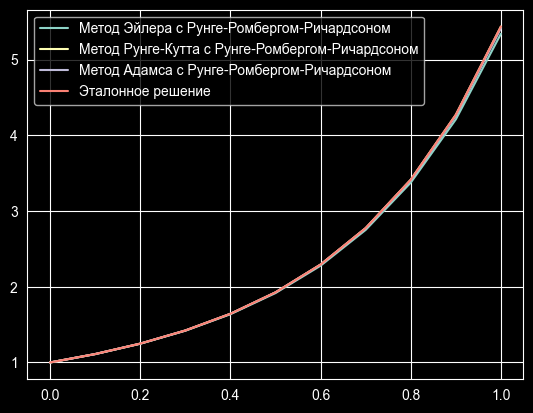

In [158]:
sns.lineplot(x=x, y=y_euler_runge_romberg, label='Метод Эйлера с Рунге-Ромбергом-Ричардсоном')
sns.lineplot(x=x, y=y_runge_kutta_runge_romberg, label='Метод Рунге-Кутта с Рунге-Ромбергом-Ричардсоном')
sns.lineplot(x=x, y=y_adams_runge_romberg, label='Метод Адамса с Рунге-Ромбергом-Ричардсоном')
sns.lineplot(x=x, y=y_etalon_f, label='Эталонное решение')

In [159]:
print("Погрешность метода Эйлера с Рунге-Ромбергом-Ричардсоном:", error(y_euler_runge_romberg, y_etalon_f))
print("Погрешность метода Рунге-Кутта с Рунге-Ромбергом-Ричардсоном:", error(y_runge_kutta_runge_romberg, y_etalon_f))
print("Погрешность метода Адамса с Рунге-Ромбергом-Ричардсоном:", error(y_adams_runge_romberg, y_etalon_f))

Погрешность метода Эйлера с Рунге-Ромбергом-Ричардсоном: 0.25910783314719277
Погрешность метода Рунге-Кутта с Рунге-Ромбергом-Ричардсоном: 0.0009050781446588996
Погрешность метода Адамса с Рунге-Ромбергом-Ричардсоном: 0.053685829495393245
